# 論文に合わせた全年数のデータセット
論文では2016年4月1日-2022年3月31日のデータを使ってデータ分析をしている

In [1]:
import sys
from pathlib import Path
# projectルートを追加
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8


In [2]:
from pathlib import Path
import pandas as pd

base_path = Path("../data/raw")

dfs = []

for year in range(2016, 2023):  # 2022まで
    csv_path = base_path / f"spot_summary_{year}.csv"
    df_year = pd.read_csv(csv_path, encoding="cp932")
    dfs.append(df_year)

# 結合
df = pd.concat(dfs, ignore_index=True)

# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = (
    df["受渡日"]
    + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")
)

# indexに設定
df = df.set_index("datetime").sort_index()

df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
datetime,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN


In [3]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
datetime,,,,,,,,,,,,,,,,,,,
2023-03-31 21:30:00,2023-03-31,44,22677650,18321400,16369050,11.20,11.21,11.21,11.21,11.21,10.48,10.48,10.48,10.48,10.48,6685350,2428900,2124500.0,2124500.0
2023-03-31 22:00:00,2023-03-31,45,22110200,18338950,16125950,11.21,11.22,11.22,11.22,11.22,10.48,10.48,10.48,10.48,10.48,6650750,2387900,1902550.0,1902550.0
2023-03-31 22:30:00,2023-03-31,46,21926550,18250000,16282250,11.09,11.19,11.19,11.19,11.19,9.33,9.33,9.33,9.33,9.33,6306050,2382150,1739550.0,1739550.0
2023-03-31 23:00:00,2023-03-31,47,21015400,17926750,15776700,11.21,11.22,11.22,11.22,11.22,9.33,9.33,9.33,9.33,9.33,5887100,2331700,1529400.0,1529400.0
2023-03-31 23:30:00,2023-03-31,48,20266250,17251650,15628850,10.00,11.21,11.21,11.21,11.21,8.99,8.99,8.99,8.99,8.99,5301300,2325900,1021800.0,1021800.0


In [4]:
len(df)

122688

In [6]:
import pandas as pd

# エリアプライス列だけ抽出
area_cols = [col for col in df.columns if "エリアプライス" in col]

# 統計量計算
stats = pd.DataFrame({
    "mean": df[area_cols].mean(),
    "median": df[area_cols].median(),
    "std": df[area_cols].std(),
    "skew": df[area_cols].skew(),
    "95": df[area_cols].quantile(0.95) # 歪度　スパイクが起きているのでsknw>0になる可能性が
})

stats

,mean,median,std,skew,95
エリアプライス北海道(円/kWh),14.009332,11.22,12.495809,7.168585,30.0000
エリアプライス東北(円/kWh),12.357039,9.14,12.591754,7.422135,29.6000
エリアプライス東京(円/kWh),12.721581,9.26,12.875528,7.274940,30.0000
エリアプライス中部(円/kWh),11.469875,8.21,11.558085,7.127349,27.3065
エリアプライス北陸(円/kWh),11.267036,8.18,11.261334,7.555475,26.0000
エリアプライス関西(円/kWh),11.257597,8.19,11.248292,7.579691,25.9500
エリアプライス中国(円/kWh),11.204372,8.18,11.182130,7.687822,25.6365
エリアプライス四国(円/kWh),11.183935,8.18,11.183324,7.756295,25.5000
エリアプライス九州(円/kWh),9.907720,7.64,10.701292,8.782815,22.9800


## データ加工（休日、平日の区別をなくす）
論文は、曜日効果と季節効果を消すスケール係数を導入している
$$
y_d^{a,t} = k^{a , t}_d \ y^{a,t^{'}}_d
$$

ただ、論文のスケーリング係数がわからないので以下を仮定する
$$
k^{a,t}_d = \frac{\text{day d までの平日平均価格}}{\text{day d までの休日平均価格}}
$$

こうすることで曜日による差を除去し、Hawkesが自己励起ではなく、周期性を学習しないようにしている（平日だから起きやすいという偏相関を消す）

In [7]:
import numpy as np
import pandas as pd

# エリア列
area_cols = [col for col in df.columns if "エリアプライス" in col]

# 休日フラグ（土日ベース）
df = df.copy()
df["is_weekend"] = df.index.weekday >= 5

# スケーリング後データ
df_scaled = df.copy()

for col in area_cols:
    # 各列ごとに係数格納用
    k_all = pd.Series(index=df.index, dtype=float)

    # 時刻コードごとに処理
    for t, g in df[["時刻コード", "is_weekend", col]].groupby("時刻コード", sort=True):
        g = g.sort_index().copy()

        # 平日・休日の価格を分離
        weekend_price = g[col].where(g["is_weekend"])
        weekday_price = g[col].where(~g["is_weekend"])

        # day d までの累積和・累積件数
        cum_weekend_sum = weekend_price.fillna(0).cumsum()
        cum_weekend_cnt = g["is_weekend"].astype(int).cumsum()

        cum_weekday_sum = weekday_price.fillna(0).cumsum()
        cum_weekday_cnt = (~g["is_weekend"]).astype(int).cumsum()

        # day d までの累積平均
        weekend_mean_d = cum_weekend_sum / cum_weekend_cnt.replace(0, np.nan)
        weekday_mean_d = cum_weekday_sum / cum_weekday_cnt.replace(0, np.nan)

        # 正しい係数：
        # k_d^{a,t} = (day d までの workday 平均) / (day d までの non-workday 平均)
        k_d = weekday_mean_d / weekend_mean_d.replace(0, np.nan)

        k_all.loc[g.index] = k_d

    # 未定義部分は1.0
    k_all = k_all.fillna(1.0)

    # 休日だけ補正
    mask = df["is_weekend"]
    df_scaled.loc[mask, col] = df.loc[mask, col] * k_all.loc[mask]

    # 確認用に係数列を残す
    df_scaled[f"{col}_k"] = k_all

In [8]:
area_cols_scaled = [
    col for col in df_scaled.columns
    if "エリアプライス" in col and not col.endswith("_k")
]

df_statistics = pd.DataFrame({
    "mean": df_scaled[area_cols_scaled].mean(),
    "median": df_scaled[area_cols_scaled].median(),
    "std": df_scaled[area_cols_scaled].std(),
    "skew": df_scaled[area_cols_scaled].skew(),
    "95": df_scaled[area_cols_scaled].quantile(0.95),
})

df_statistics

,mean,median,std,skew,95
エリアプライス北海道(円/kWh),14.646476,11.630000,12.881528,6.874540,32.100000
エリアプライス東北(円/kWh),13.057772,9.693571,13.013724,7.148145,30.740000
エリアプライス東京(円/kWh),13.458925,9.856848,13.311518,6.985009,32.085633
エリアプライス中部(円/kWh),12.124541,8.730000,11.976370,6.776184,29.348526
エリアプライス北陸(円/kWh),11.917622,8.712717,11.686229,7.174125,28.160000
エリアプライス関西(円/kWh),11.900129,8.710000,11.671492,7.198626,28.040000
エリアプライス中国(円/kWh),11.842348,8.700000,11.604883,7.298983,27.695740
エリアプライス四国(円/kWh),11.820267,8.700000,11.602175,7.365682,27.475490
エリアプライス九州(円/kWh),10.483391,8.117488,11.098578,8.394700,24.291246


生データでは、平日についてスパイクが起きやすくなっているため、累積分布が1に近づくまでに時間がかかっている。

それをスケール係数で変換したことによって平日と休日の累積分布が近くなっている。

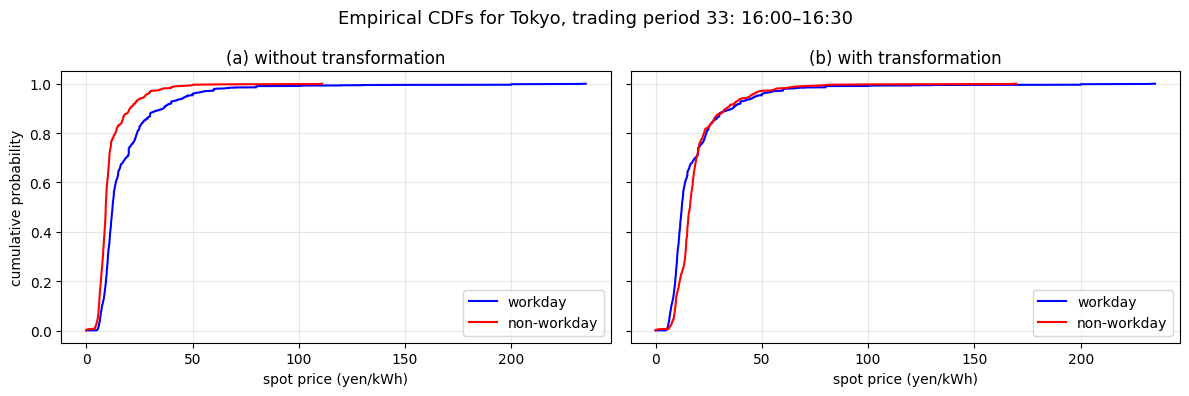

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 設定
# -----------------------------
area_col = "エリアプライス東京(円/kWh)"
time_code = 33   # 論文図4の例
label_area = "Tokyo"
label_time = "trading period 33: 16:00–16:30"

# is_weekend がなければ作成
if "is_weekend" not in df.columns:
    df = df.copy()
    df["is_weekend"] = df.index.weekday >= 5

if "is_weekend" not in df_scaled.columns:
    df_scaled = df_scaled.copy()
    df_scaled["is_weekend"] = df_scaled.index.weekday >= 5


# -----------------------------
# ECDF関数
# -----------------------------
def ecdf_values(x):
    x = pd.Series(x).dropna().to_numpy()
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


# -----------------------------
# データ抽出
# -----------------------------
# 補正前
raw_sub = df[df["時刻コード"] == time_code]
raw_weekday = raw_sub.loc[~raw_sub["is_weekend"], area_col]
raw_nonwork = raw_sub.loc[raw_sub["is_weekend"], area_col]

# 補正後
scaled_sub = df_scaled[df_scaled["時刻コード"] == time_code]
scaled_weekday = scaled_sub.loc[~scaled_sub["is_weekend"], area_col]
scaled_nonwork = scaled_sub.loc[scaled_sub["is_weekend"], area_col]

# ECDF
x_rw, y_rw = ecdf_values(raw_weekday)
x_rn, y_rn = ecdf_values(raw_nonwork)

x_sw, y_sw = ecdf_values(scaled_weekday)
x_sn, y_sn = ecdf_values(scaled_nonwork)


# -----------------------------
# プロット
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# (a) 補正前
axes[0].plot(x_rw, y_rw, label="workday", color="blue")
axes[0].plot(x_rn, y_rn, label="non-workday", color="red")
axes[0].set_title("(a) without transformation")
axes[0].set_xlabel("spot price (yen/kWh)")
axes[0].set_ylabel("cumulative probability")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# (b) 補正後
axes[1].plot(x_sw, y_sw, label="workday", color="blue")
axes[1].plot(x_sn, y_sn, label="non-workday", color="red")
axes[1].set_title("(b) with transformation")
axes[1].set_xlabel("spot price (yen/kWh)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(f"Empirical CDFs for {label_area}, {label_time}", fontsize=13)
plt.tight_layout()
plt.show()

## データ加工（時間による周期性をなくす）
電力データは時間帯による周期性も存在する

これはスケール係数などをかけるのではなく、データ分析として別の時系列として見てモデリングをする

$a:\text{エリア},t:\text{時間帯}$
$$
y_{d}^{a,t}
$$

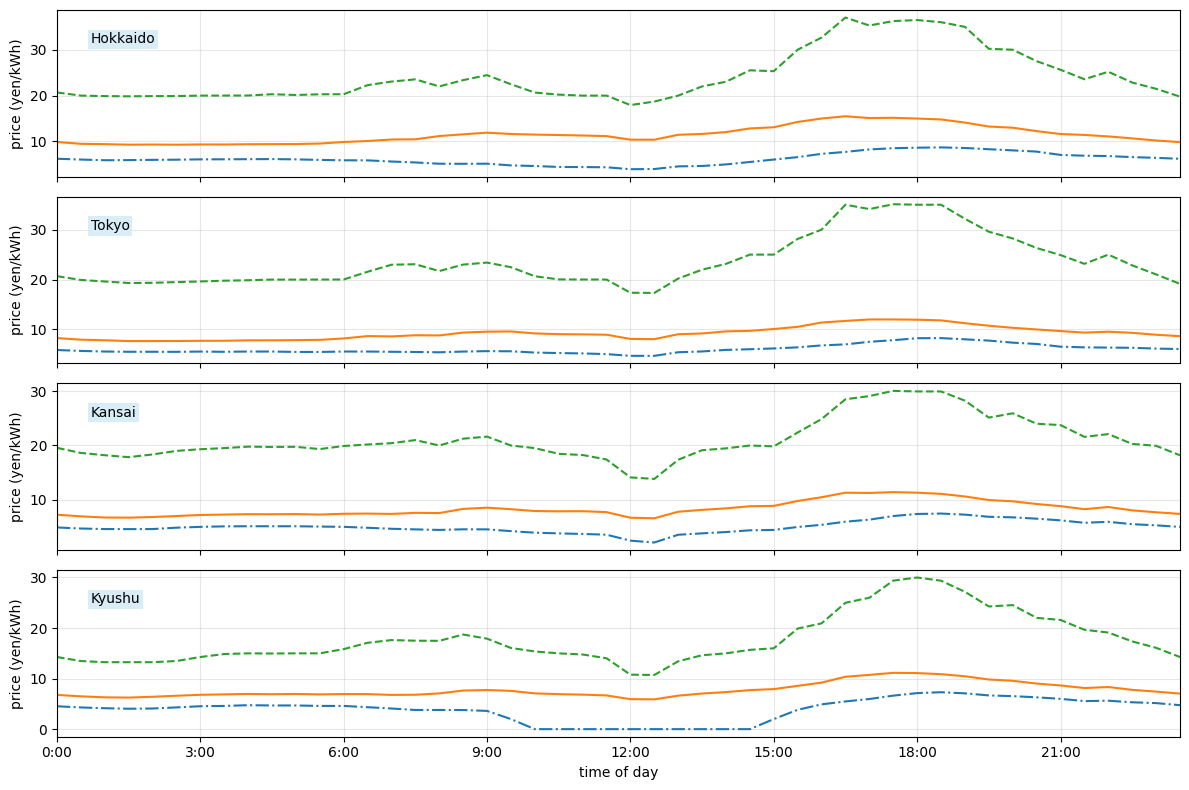

In [54]:
# Fig 5
import pandas as pd
import matplotlib.pyplot as plt

# 対象エリア
area_map = {
    "Hokkaido": "エリアプライス北海道(円/kWh)",
    "Tokyo": "エリアプライス東京(円/kWh)",
    "Kansai": "エリアプライス関西(円/kWh)",
    "Kyushu": "エリアプライス九州(円/kWh)",
}

# 時刻コードごとの統計量を計算
stats_by_time = {}

for area_name, col in area_map.items():
    g = df.groupby("時刻コード")[col]
    stats_by_time[area_name] = pd.DataFrame({
        "p10": g.quantile(0.10),
        "median": g.median(),
        "p90": g.quantile(0.90),
    })

# x軸ラベル（3時間おき）
tick_positions = [1, 7, 13, 19, 25, 31, 37, 43]
tick_labels = ["0:00", "3:00", "6:00", "9:00", "12:00", "15:00", "18:00", "21:00"]

# プロット
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for ax, (area_name, stat_df) in zip(axes, stats_by_time.items()):
    x = stat_df.index

    ax.plot(x, stat_df["p10"], linestyle="-.", label="10th percentile")
    ax.plot(x, stat_df["median"], linestyle="-", label="median")
    ax.plot(x, stat_df["p90"], linestyle="--", label="90th percentile")

    ax.set_ylabel("price (yen/kWh)")
    ax.set_xlim(1, 48)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.grid(True, alpha=0.3)

    # 論文風のエリアラベル
    ax.text(
        0.03, 0.80, area_name,
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor="#d9edf7", edgecolor="none", pad=2)
    )

axes[-1].set_xlabel("time of day")
plt.tight_layout()
plt.show()

## データ加工（スパイクデータ系列への変換）
論文では、価格データを直接扱うのではなく、ある閾値を超えた（スパイク）かどうかをモデリングする。閾値は共通で$25$。

上段
$$
u_{d}^{a,t} =
\begin{cases}
1 & (y_{d}^{a,t}> y^{\delta}) \\
0 & (\text{otherwise})
\end{cases}
$$

下段
$$
x_{d}^{a,t} =
\begin{cases}
0 & (u_{d}^{a,t} = 0) \\
y_{d}^{a,t} - y^{\delta} & (u_{d}^{a,t} = 1)
\end{cases}
$$

データを観察しても

> スパイクはランダムではなく「クラスターを作る」

つまり、一度起きると、しばらく発生しやすくなるといえそう。これをHawkesでモデル化していく。

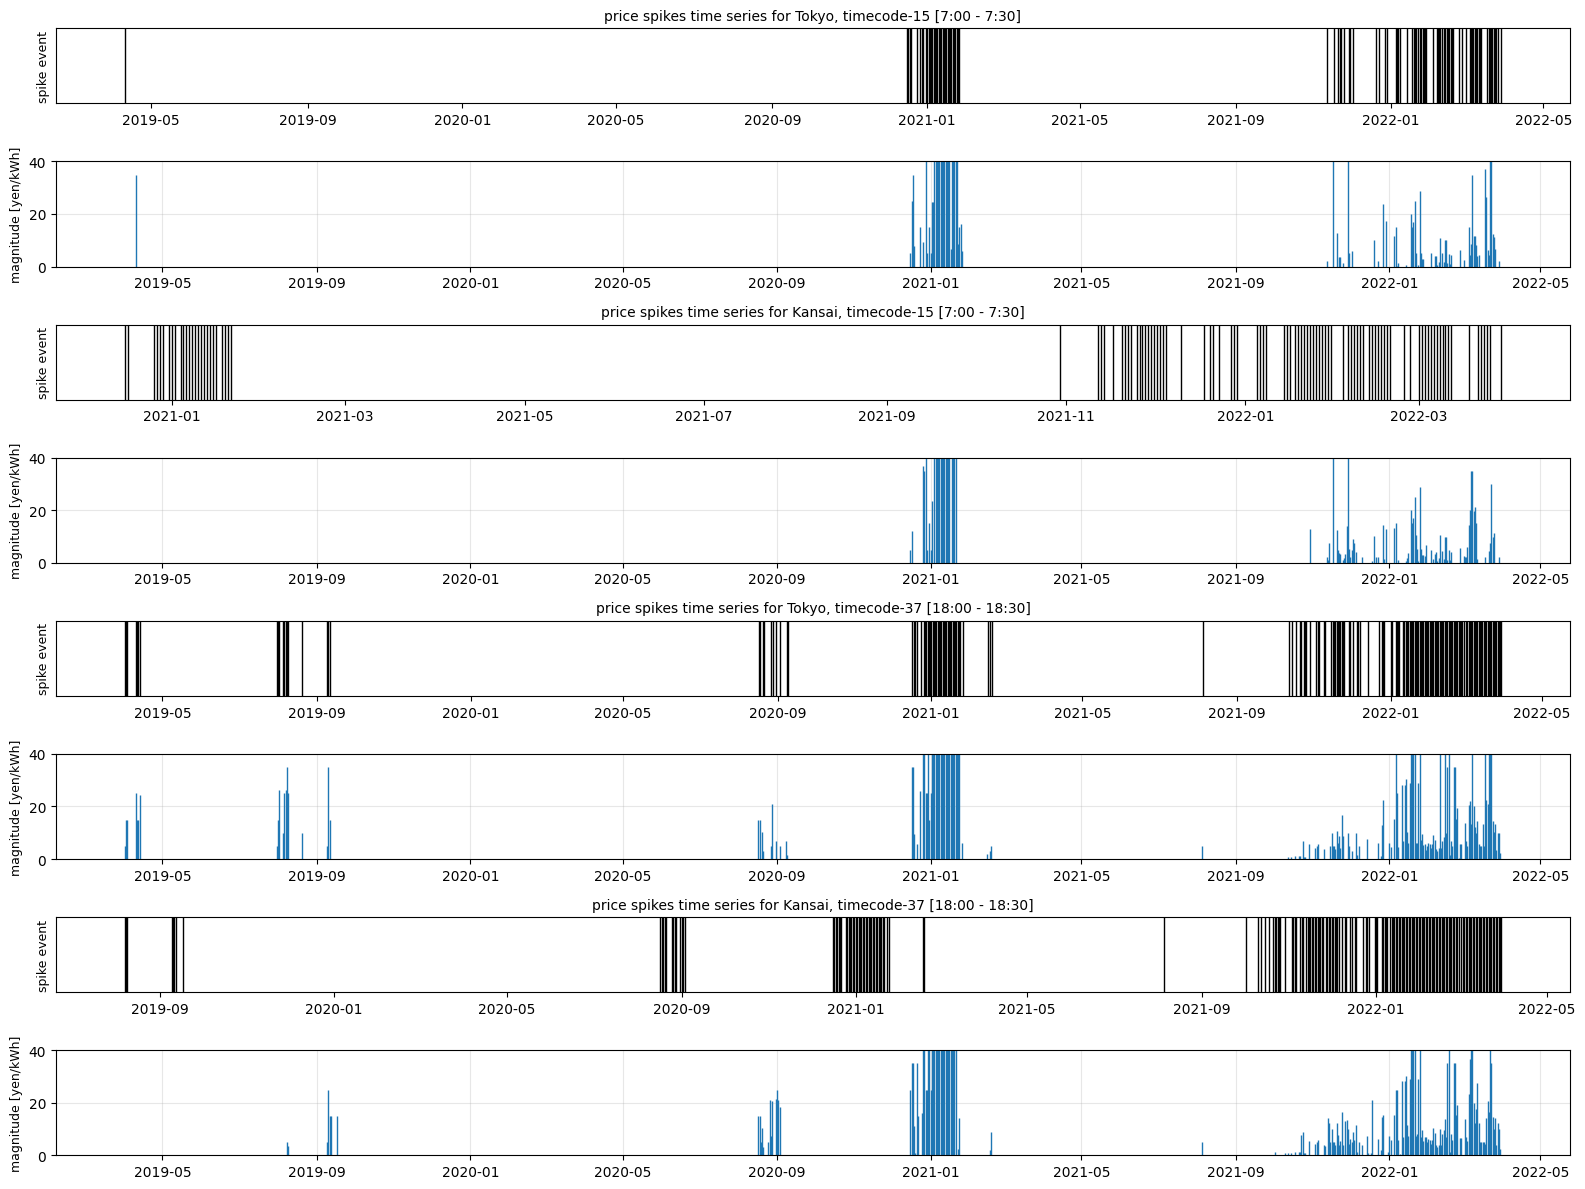

In [55]:
# Fig6
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 前提
# =========================
# df_scaled:
#   DatetimeIndex を持つ DataFrame
#   例: 列 "エリアプライス東京(円/kWh)", "エリアプライス関西(円/kWh)"
#
# まだ index が datetime でない場合は事前に整えておく
# df_scaled.index = pd.to_datetime(df_scaled.index)

# =========================
# パラメータ
# =========================
threshold = 25.0

# 論文の図6で使われている代表例
# timecode-15 = 7:00 - 7:30
# timecode-37 = 18:00 - 18:30
selected_cases = [
    ("東京", "エリアプライス東京(円/kWh)", 15, "Tokyo"),
    ("関西", "エリアプライス関西(円/kWh)", 15, "Kansai"),
    ("東京", "エリアプライス東京(円/kWh)", 37, "Tokyo"),
    ("関西", "エリアプライス関西(円/kWh)", 37, "Kansai"),
]

# 図6は 2019-04 〜 2022-03 を描いている
plot_start = "2019-04-01"
plot_end   = "2022-03-31"

# =========================
# 時刻コード列を作る関数
# =========================
def add_timecode_from_index(df):
    df = df.copy()
    minutes = df.index.hour * 60 + df.index.minute
    df["時刻コード"] = (minutes // 30) + 1
    return df

# =========================
# 1ケース分のスパイク系列を作る関数
# =========================
def make_spike_series(df, price_col, timecode, threshold=25.0):
    """
    ある price_col, timecode に対して
    日次のスパイク発生系列 u_d と magnitude x_d を返す

    u_d = 1(price > threshold)
    x_d = max(price - threshold, 0)
    """
    tmp = df[[price_col, "時刻コード"]].copy()
    tmp = tmp[tmp["時刻コード"] == timecode].copy()

    # 1日1点になるはず
    tmp["date"] = tmp.index.normalize()

    # 念のため日単位にまとめる
    daily = (
        tmp.groupby("date")[price_col]
        .first()
        .to_frame(name="price")
        .sort_index()
    )

    daily["u"] = (daily["price"] > threshold).astype(int)
    daily["x"] = (daily["price"] - threshold).clip(lower=0)

    return daily

# =========================
# 作図用データ作成
# =========================
df_fig6 = add_timecode_from_index(df_scaled)

# プロット期間に絞る
df_fig6 = df_fig6.loc[plot_start:plot_end].copy()

series_list = []
for area_ja, col, tc, area_en in selected_cases:
    daily = make_spike_series(df_fig6, col, tc, threshold=threshold)
    series_list.append((area_ja, area_en, tc, daily))

# =========================
# 図6プロット
# =========================
fig, axes = plt.subplots(
    nrows=8, ncols=1,
    figsize=(16, 12),
    sharex=False,
    gridspec_kw={"height_ratios": [1, 1.4, 1, 1.4, 1, 1.4, 1, 1.4]}
)

for i, (area_ja, area_en, tc, daily) in enumerate(series_list):
    ax_top = axes[2 * i]
    ax_bottom = axes[2 * i + 1]

    # ---------- 上段: barcode plot ----------
    spike_dates = daily.index[daily["u"] == 1]
    ax_top.vlines(spike_dates, ymin=0, ymax=1, color="black", linewidth=1)

    # timecode -> 時間帯ラベル
    start_minutes = (tc - 1) * 30
    end_minutes = start_minutes + 30
    sh, sm = divmod(start_minutes, 60)
    eh, em = divmod(end_minutes, 60)

    ax_top.set_ylim(0, 1)
    ax_top.set_yticks([])
    ax_top.set_ylabel("spike event", fontsize=9)
    ax_top.set_title(
        f"price spikes time series for {area_en}, timecode-{tc} "
        f"[{sh}:{sm:02d} - {eh}:{em:02d}]",
        fontsize=10
    )

    # ---------- 下段: spike magnitude ----------
    ax_bottom.vlines(
        daily.index,
        ymin=0,
        ymax=daily["x"],
        linewidth=1
    )
    ax_bottom.set_ylabel("magnitude [yen/kWh]", fontsize=9)
    ax_bottom.set_ylim(0, 40)   # 論文と同じく40で打ち切り
    ax_bottom.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()